# Моделирование LTV 

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [14]:
PROCESSED_PATH = 'data/processed'
FEATURES_FILE = os.path.join(PROCESSED_PATH, 'features_.csv')

df = pd.read_csv(FEATURES_FILE)
print(f"Загружено строк: {len(df):,}")
print(f"will_return = 1: {df['will_return'].sum():,} ({df['will_return'].mean():.2%})")

Загружено строк: 42,395
will_return = 1: 649 (1.53%)


## Подготовка данных

In [15]:
exclude = ['customer_unique_id', 'future_ltv', 'will_return']
features = [c for c in df.columns if c not in exclude]

X = df[features].astype(float)
y = df['will_return']
y_ltv = df['future_ltv']

# Средний чек только среди тех, кто реально вернулся (для формулы LTV)
avg_return_amount = y_ltv[y_ltv > 0].mean()
print(f"Признаков: {len(features)}")
print(f"Средний повторный чек (returners): {avg_return_amount:.2f} R$")
print(f"Позитивов: {y.sum()} ({y.mean():.2%})")

Признаков: 42
Средний повторный чек (returners): 229.83 R$
Позитивов: 649 (1.53%)


## Кросс-валидация (StratifiedKFold)


In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(X))
metrics = []

scale_pos_weight = (y == 0).sum() / max(1, (y == 1).sum())

last_models = {}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb = XGBClassifier(n_estimators=300,
                        max_depth=5,
                        learning_rate=0.05,
                        scale_pos_weight=scale_pos_weight,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42,
                        eval_metric='auc',
                        n_jobs=-1)
    lgbm = LGBMClassifier(n_estimators=300,
                          max_depth=5,
                          learning_rate=0.05,
                          is_unbalance=True,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          random_state=42,
                          verbose=-1,
                          n_jobs=-1)
    cat = CatBoostClassifier(iterations=300,
                             depth=5,
                             learning_rate=0.05,
                             auto_class_weights='Balanced',
                             random_state=42,
                             verbose=0)

    xgb.fit(X_tr, y_tr)
    lgbm.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)

    proba = (xgb.predict_proba(X_val)[:, 1] + lgbm.predict_proba(X_val)[:, 1] +
             cat.predict_proba(X_val)[:, 1]) / 3

    oof_proba[val_idx] = proba

    roc = roc_auc_score(y_val, proba)
    pr = average_precision_score(y_val, proba)
    metrics.append({'fold': fold, 'roc_auc': roc, 'pr_auc': pr})

    if fold == 5:
        last_models = {'xgb': xgb, 'lgbm': lgbm, 'cat': cat}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)
print(
    f"\nMean ROC-AUC: {metrics_df['roc_auc'].mean():.4f} ± {metrics_df['roc_auc'].std():.4f}"
)
print(
    f"Mean PR-AUC:  {metrics_df['pr_auc'].mean():.4f} ± {metrics_df['pr_auc'].std():.4f}"
)

   fold  roc_auc  pr_auc
0     1   0.5001  0.0364
1     2   0.5477  0.0300
2     3   0.5680  0.0347
3     4   0.5090  0.0267
4     5   0.5551  0.0279

Mean ROC-AUC: 0.5360 ± 0.0298
Mean PR-AUC:  0.0311 ± 0.0042


In [17]:
# Сохраняем модели последнего фолда
joblib.dump(last_models, 'ltv_clf_models_fixed.pkl')
print("Модели сохранены: ltv_clf_models_fixed.pkl")

Модели сохранены: ltv_clf_models_fixed.pkl


## Метрики качества (OOF)

In [18]:
print("=== OOF Metrics ===")
print(f"ROC-AUC: {roc_auc_score(y, oof_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y, oof_proba):.4f}")

# Precision / Recall при разных порогах
for thr in [0.1, 0.2, 0.3, 0.5]:
    pred = (oof_proba >= thr).astype(int)
    if pred.sum() == 0:
        continue
    p = precision_score(y, pred)
    r = recall_score(y, pred)
    f1 = f1_score(y, pred)
    print(
        f"Threshold {thr:.1f} → Precision: {p:.3f}, Recall: {r:.3f}, F1: {f1:.3f}, Pos predicted: {pred.sum()}"
    )

=== OOF Metrics ===
ROC-AUC: 0.5357
PR-AUC:  0.0284
Threshold 0.1 → Precision: 0.016, Recall: 0.971, F1: 0.031, Pos predicted: 40158
Threshold 0.2 → Precision: 0.016, Recall: 0.852, F1: 0.031, Pos predicted: 35465
Threshold 0.3 → Precision: 0.016, Recall: 0.723, F1: 0.032, Pos predicted: 29012
Threshold 0.5 → Precision: 0.018, Recall: 0.233, F1: 0.033, Pos predicted: 8488


In [19]:
# Precision@K и Lift
def precision_at_k(y_true, proba, k):
    idx = np.argsort(proba)[::-1][:k]
    return y_true.iloc[idx].mean()


base_rate = y.mean()
print("\n=== Precision@K / Lift ===")
for k in [100, 500, 1000, 2000, 5000]:
    p_at_k = precision_at_k(y, oof_proba, k)
    lift = p_at_k / base_rate
    print(f"Top-{k:5d}: Precision={p_at_k:.3f}, Lift={lift:.1f}x")


=== Precision@K / Lift ===
Top-  100: Precision=0.110, Lift=7.2x
Top-  500: Precision=0.042, Lift=2.7x
Top- 1000: Precision=0.030, Lift=2.0x
Top- 2000: Precision=0.021, Lift=1.4x
Top- 5000: Precision=0.018, Lift=1.2x


## Предсказанный LTV

LTV ≈ P(return) × средний чек тех, кто вернулся

In [20]:
df['pred_proba'] = oof_proba
df['pred_ltv'] = oof_proba * avg_return_amount

print("Статистика pred_ltv:")
print(df['pred_ltv'].describe())
print(f"\nСредний pred_ltv: {df['pred_ltv'].mean():.2f} R$")
print(f"Доля pred_ltv > 0: {(df['pred_ltv'] > 0).mean():.2%}")

Статистика pred_ltv:
count   42395.0000
mean       84.5177
std        34.6755
min         0.4038
25%        59.9020
50%        88.5768
75%       110.2870
max       226.5469
Name: pred_ltv, dtype: float64

Средний pred_ltv: 84.52 R$
Доля pred_ltv > 0: 100.00%


## Сегментация по предсказанному LTV

In [21]:
# Децили по pred_ltv
df['ltv_decile'] = pd.qcut(
    df['pred_ltv'], q=10, labels=False, duplicates='drop') + 1

segment_stats = (df.groupby('ltv_decile').agg(
    count=('customer_unique_id', 'count'),
    mean_pred_ltv=('pred_ltv', 'mean'),
    mean_proba=('pred_proba', 'mean'),
    actual_return_rate=('will_return', 'mean'),
    actual_avg_ltv=('future_ltv', 'mean')).round(3))
segment_stats['share'] = (segment_stats['count'] / len(df)).round(3)

print("Сегменты по децилям pred_ltv:")
print(segment_stats)

Сегменты по децилям pred_ltv:
            count  mean_pred_ltv  mean_proba  actual_return_rate  \
ltv_decile                                                         
1            4240        21.1010      0.0920              0.0140   
2            4239        43.3560      0.1890              0.0150   
3            4240        59.8290      0.2600              0.0110   
4            4239        72.9370      0.3170              0.0130   
5            4240        83.7690      0.3640              0.0170   
6            4239        93.1850      0.4050              0.0130   
7            4239       101.8340      0.4430              0.0170   
8            4240       110.3910      0.4800              0.0180   
9            4239       120.2260      0.5230              0.0170   
10           4240       138.5520      0.6030              0.0180   

            actual_avg_ltv  share  
ltv_decile                         
1                   3.2210 0.1000  
2                   3.1620 0.1000  
3        

In [22]:
# Рекомендации
recommendations = {
    1: "Минимальные усилия: общие рассылки 1 раз в квартал",
    2: "Лёгкие напоминания: скидка 5%",
    3: "Базовые акции: скидка 10% + email-рекомендации",
    4: "Персонализация: рекомендации по категориям + скидка 12%",
    5: "Средний уровень: кросс-продажи, бандлы, скидка 15%",
    6: "Активное удержание: персональные предложения, cashback",
    7: "Высокий приоритет: VIP-скидки 20–25%, ранний доступ",
    8: "Премиум: персональный менеджер, эксклюзивные акции",
    9: "Топ-клиенты: бонусы за лояльность, подарки",
    10: "Максимум внимания: индивидуальные предложения, VIP-события"
}

print("\n=== Рекомендации по сегментам ===")
for decile, rec in recommendations.items():
    if decile in segment_stats.index:
        row = segment_stats.loc[decile]
        print(
            f"Decile {decile:2d} | n={int(row['count']):5d} | pred_LTV={row['mean_pred_ltv']:6.1f} | "
            f"actual return={row['actual_return_rate']:.1%} → {rec}")


=== Рекомендации по сегментам ===
Decile  1 | n= 4240 | pred_LTV=  21.1 | actual return=1.4% → Минимальные усилия: общие рассылки 1 раз в квартал
Decile  2 | n= 4239 | pred_LTV=  43.4 | actual return=1.5% → Лёгкие напоминания: скидка 5%
Decile  3 | n= 4240 | pred_LTV=  59.8 | actual return=1.1% → Базовые акции: скидка 10% + email-рекомендации
Decile  4 | n= 4239 | pred_LTV=  72.9 | actual return=1.3% → Персонализация: рекомендации по категориям + скидка 12%
Decile  5 | n= 4240 | pred_LTV=  83.8 | actual return=1.7% → Средний уровень: кросс-продажи, бандлы, скидка 15%
Decile  6 | n= 4239 | pred_LTV=  93.2 | actual return=1.3% → Активное удержание: персональные предложения, cashback
Decile  7 | n= 4239 | pred_LTV= 101.8 | actual return=1.7% → Высокий приоритет: VIP-скидки 20–25%, ранний доступ
Decile  8 | n= 4240 | pred_LTV= 110.4 | actual return=1.8% → Премиум: персональный менеджер, эксклюзивные акции
Decile  9 | n= 4239 | pred_LTV= 120.2 | actual return=1.7% → Топ-клиенты: бонусы за 

## Feature Importance (из последнего XGBoost)

In [23]:
imp = pd.Series(last_models['xgb'].feature_importances_,
                index=features).sort_values(ascending=False)

print("Top-15 признаков:")
print(imp.head(15))

Top-15 признаков:
freq_x_diversity          0.0515
frequency                 0.0464
state_CE                  0.0316
avg_days_between_orders   0.0309
state_BA                  0.0298
payment_credit_card       0.0295
state_SP                  0.0293
monetary_per_order        0.0282
state_DF                  0.0279
payment_debit_card        0.0279
payment_voucher           0.0278
payment_boleto            0.0276
state_PE                  0.0274
first_purchase_day        0.0272
last_purchase_day         0.0270
dtype: float32


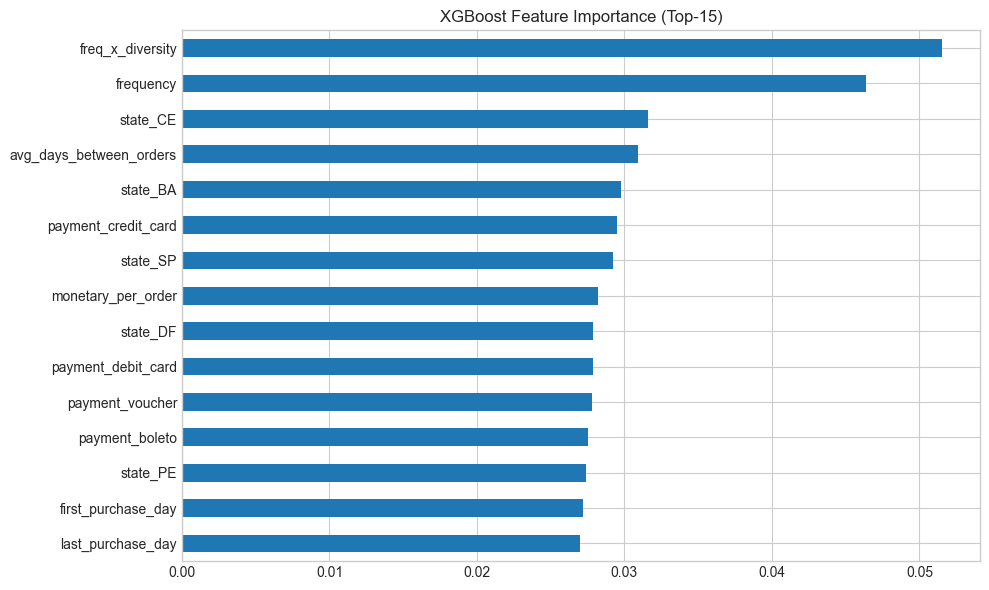

In [24]:
plt.figure(figsize=(10, 6))
imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (Top-15)')
plt.tight_layout()
plt.show()

## Итог

- Time-split = тысячи позитивов.
- Метрики (ROC-AUC + PR-AUC + Precision@K).
- Сегментация по децилям может использоваться для маркетинга.
- Модели сохранены в `ltv_clf_models_fixed.pkl`.